Mounted at /content/drive
Sample size: 363, Number of features: 20
0
Label
0    287
1     76
Name: count, dtype: int64


/tmp/ipykernel_644/2991264678.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='Pastel1')


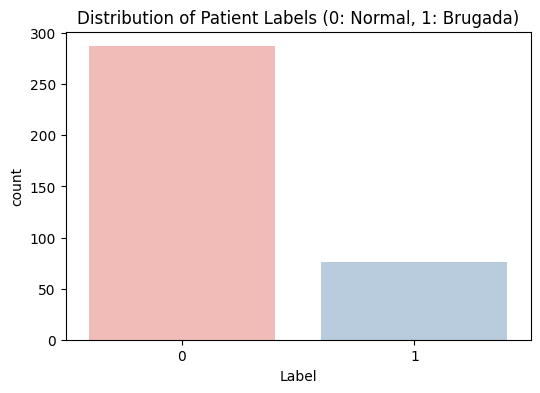

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load data
df = pd.read_csv('/content/drive/MyDrive/IDSC2026_Brugada_Project/brugada_features_V1_to_V3.csv')

print(f"Sample size: {df.shape[0]}, Number of features: {df.shape[1]}")
print(df.isnull().sum().sum())

label_counts = df['Label'].value_counts()
print(label_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=df, palette='Pastel1')
plt.title('Distribution of Patient Labels (0: Normal, 1: Brugada)')
plt.show()

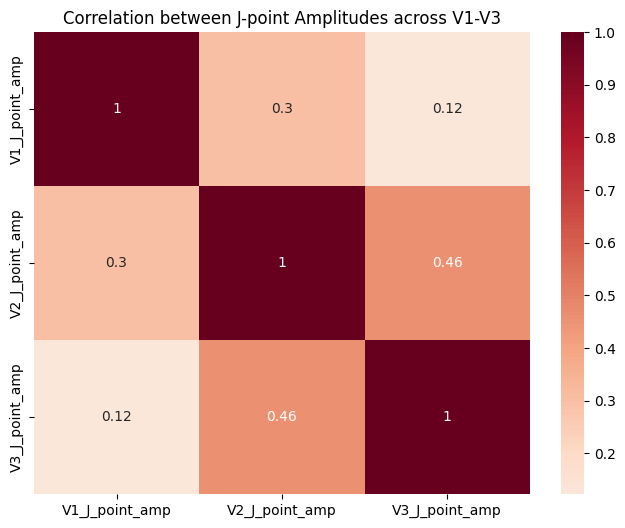

In [2]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(['Patient_ID', 'Label'], axis=1)

# Correlation of J point amplitudes for each lead (V1, V2, V3)
j_point_cols = [col for col in df.columns if 'J_point_amp' in col]
corr_matrix = X[j_point_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation between J-point Amplitudes across V1-V3')
plt.show()

In [3]:
############### T test ##################

from scipy import stats

all_features = [col for col in df.columns if col not in ['Patient_ID', 'Label']]
results = []

for col in all_features:
    group1 = df[df['Label'] == 1][col] # Brugada
    group0 = df[df['Label'] == 0][col] # Normal

    t_stat, p_val = stats.ttest_ind(group1, group0, nan_policy='omit')
    results.append({'Feature': col, 'P_Value': p_val, 'T_Stat': t_stat})

# Convert into data frame and sort by p value
t_test_df = pd.DataFrame(results).sort_values(by='P_Value')

t_test_df['Significant'] = t_test_df['P_Value'] < 0.05

# Set display option for float format to 4 decimal places
pd.options.display.float_format = '{:.4f}'.format
print(t_test_df)

# Reset display option to default if needed later:
# pd.reset_option('display.float_format')

               Feature  P_Value  T_Stat  Significant
13         V3_ST_slope   0.0000  5.5058         True
12      V3_J_point_amp   0.0000 -4.8821         True
7          V2_ST_slope   0.0000  4.4937         True
1          V1_ST_slope   0.0000 -4.2103         True
0       V1_J_point_amp   0.0001  4.0791         True
2   V1_95th_Percentile   0.0001  3.8486         True
5       V1_Min_Voltage   0.0053  2.8032         True
6       V2_J_point_amp   0.0238 -2.2706         True
14  V3_95th_Percentile   0.0466 -1.9967         True
8   V2_95th_Percentile   0.0738 -1.7933        False
11      V2_Min_Voltage   0.1053  1.6237        False
10     V2_Peak_to_Peak   0.1410 -1.4754        False
4      V1_Peak_to_Peak   0.2026 -1.2766        False
17      V3_Min_Voltage   0.2631 -1.1208        False
15          V3_Std_Dev   0.4808  0.7057        False
9           V2_Std_Dev   0.4960 -0.6815        False
16     V3_Peak_to_Peak   0.6050  0.5177        False
3           V1_Std_Dev   0.7758 -0.2850       

In [4]:
### Bonferroni

from statsmodels.stats.multitest import multipletests

p_values = t_test_df['P_Value'].values

reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

t_test_df['P_Value_Corrected'] = pvals_corrected
t_test_df['Significant_After_Correction'] = reject

# Significant features after correction
sign_features = t_test_df[t_test_df['Significant_After_Correction'] == True]
print(sign_features)

               Feature  P_Value  T_Stat  Significant  P_Value_Corrected  \
13         V3_ST_slope   0.0000  5.5058         True             0.0000   
12      V3_J_point_amp   0.0000 -4.8821         True             0.0000   
7          V2_ST_slope   0.0000  4.4937         True             0.0002   
1          V1_ST_slope   0.0000 -4.2103         True             0.0006   
0       V1_J_point_amp   0.0001  4.0791         True             0.0010   
2   V1_95th_Percentile   0.0001  3.8486         True             0.0025   

    Significant_After_Correction  
13                          True  
12                          True  
7                           True  
1                           True  
0                           True  
2                           True  


In [5]:
# T test for J_point_amp (V1, V2, V3)
for lead in ['V1', 'V2', 'V3']:
    col = f'{lead}_J_point_amp'
    brugada = df[df['Label'] == 1][col]
    normal = df[df['Label'] == 0][col]
    t_stat, p_val = stats.ttest_ind(brugada, normal)
    print(f"{col} T-test P-value: {p_val:.4f}")

V1_J_point_amp T-test P-value: 0.0001
V2_J_point_amp T-test P-value: 0.0238
V3_J_point_amp T-test P-value: 0.0000


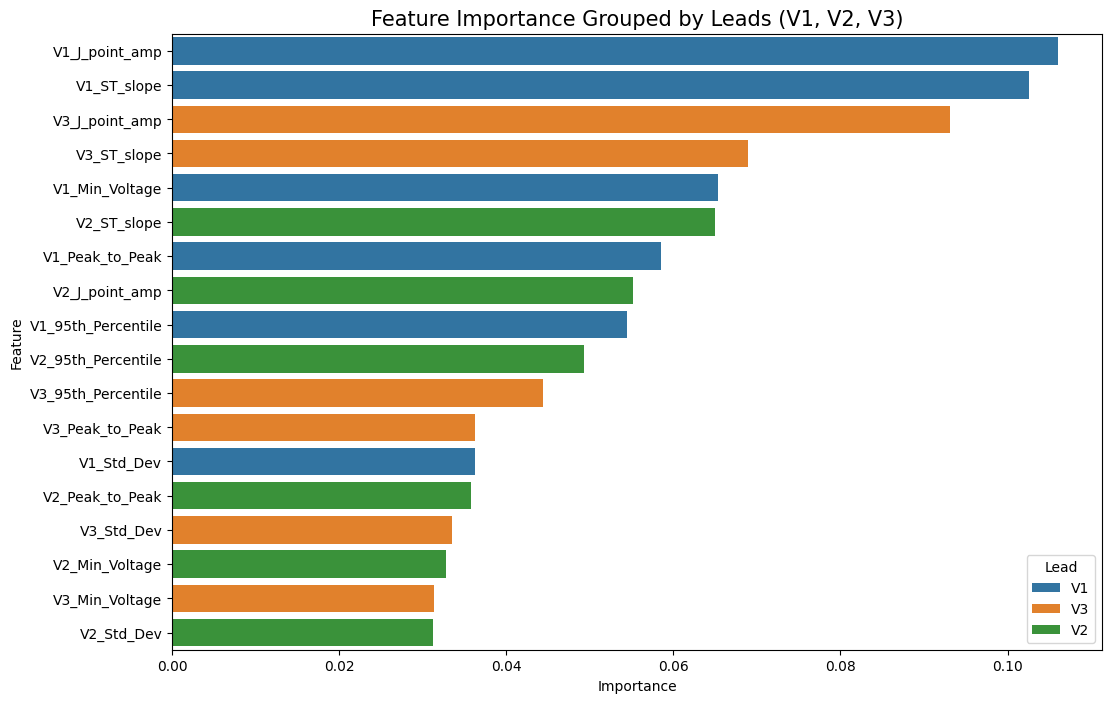

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X = df.drop(['Patient_ID', 'Label'], axis=1)
y = df['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Random Forest (Feature Importance)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_scaled, y)

feat_imp = pd.DataFrame({'Feature': X.columns,'Importance': rf.feature_importances_})

# Add Label (V1, V2, V3) for each feature
feat_imp['Lead'] = feat_imp['Feature'].apply(lambda x: x.split('_')[0])
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feat_imp, x='Importance', y='Feature', hue='Lead', dodge=False)
plt.title('Feature Importance Grouped by Leads (V1, V2, V3)', fontsize=15)
plt.show()

In [7]:
########################### VIF #################################

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#X = df.drop(['Patient_ID', 'Label'], axis=1)
X_vif = sm.add_constant(X_scaled)
vif_list = []

for i in range(1, X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.values, i)
    vif_list.append({'Feature': X_vif.columns[i], 'VIF': vif})

vif_df = pd.DataFrame(vif_list).sort_values(by='VIF', ascending=False)
print(vif_df)

               Feature     VIF
1          V1_ST_slope 33.2739
0       V1_J_point_amp 31.9726
9           V2_Std_Dev 29.2495
5       V1_Min_Voltage 24.1075
4      V1_Peak_to_Peak 21.8673
11      V2_Min_Voltage 21.3973
10     V2_Peak_to_Peak 19.5161
13         V3_ST_slope 19.1908
12      V3_J_point_amp 18.3943
7          V2_ST_slope 17.8306
3           V1_Std_Dev 17.2876
6       V2_J_point_amp 16.9174
15          V3_Std_Dev 16.2924
8   V2_95th_Percentile 10.0811
16     V3_Peak_to_Peak  9.7104
2   V1_95th_Percentile  6.2496
17      V3_Min_Voltage  5.5389
14  V3_95th_Percentile  5.2169


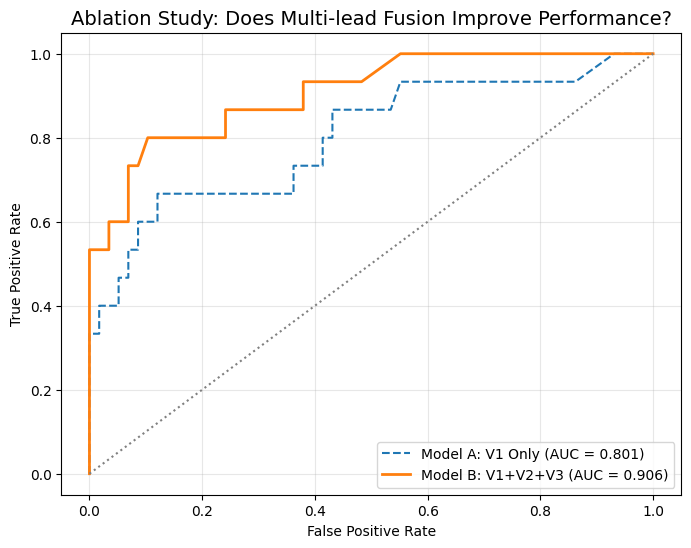

Performance Lift: 13.21% improvement


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get features V1 and all features
v1_features = [col for col in df.columns if col.startswith('V1_')]
all_features = [col for col in df.columns if col not in ['Patient_ID', 'Label']]

y = df['Label']

def evaluate_model(feature_list):
    X = df[feature_list]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)

    y_predicting = model.predict(X_test)
    y_testing = y_test
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    fpr, tpr, _ = roc_curve(y_test, probs)
    return fpr, tpr, auc, y_predicting, y_testing, probs

# Run for both features V1 and all features
fpr_v1, tpr_v1, auc_v1, y_pred_v1, y_test_v1, y_probs_v1 = evaluate_model(v1_features)
fpr_all, tpr_all, auc_all, y_pred_all, y_test_all, y_probs_all = evaluate_model(all_features)

plt.figure(figsize=(8, 6))
plt.plot(fpr_v1, tpr_v1, linestyle='--', label=f'Model A: V1 Only (AUC = {auc_v1:.3f})')
plt.plot(fpr_all, tpr_all, linewidth=2, label=f'Model B: V1+V2+V3 (AUC = {auc_all:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ablation Study: Does Multi-lead Fusion Improve Performance?', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Performance Lift: {((auc_all - auc_v1) / auc_v1 * 100):.2f}% improvement")


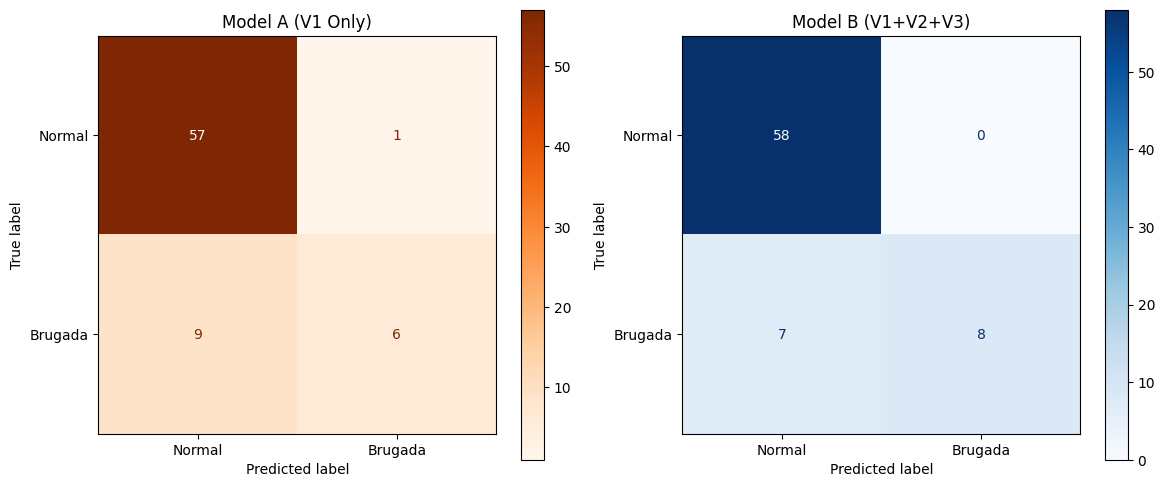

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test_v1, y_pred_v1, display_labels=['Normal', 'Brugada'], cmap='Oranges', ax=ax1)
ax1.set_title("Model A (V1 Only)")
ConfusionMatrixDisplay.from_predictions(y_test_all, y_pred_all, display_labels=['Normal', 'Brugada'], cmap='Blues', ax=ax2)
ax2.set_title("Model B (V1+V2+V3)")
plt.tight_layout()
plt.show()

In [10]:
# V1
print("Random Forest Performance (V1):")
print(classification_report(y_test_v1, y_pred_v1))
print(f"AUC Score: {roc_auc_score(y_test_v1, y_probs_v1):.4f}")

# ALL
print("\n\nRandom Forest Performance (ALL):")
print(classification_report(y_test_all, y_pred_all))
print(f"AUC Score: {roc_auc_score(y_test_all, y_probs_all):.4f}")

Random Forest Performance (V1):
              precision    recall  f1-score   support

           0       0.86      0.98      0.92        58
           1       0.86      0.40      0.55        15

    accuracy                           0.86        73
   macro avg       0.86      0.69      0.73        73
weighted avg       0.86      0.86      0.84        73

AUC Score: 0.8006


Random Forest Performance (ALL):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        58
           1       1.00      0.53      0.70        15

    accuracy                           0.90        73
   macro avg       0.95      0.77      0.82        73
weighted avg       0.91      0.90      0.89        73

AUC Score: 0.9063


In [11]:
####### Logistic Regression (Method 1) ###############

import statsmodels.api as sm

X1 = df.drop(['Patient_ID', 'Label'], axis=1)
X1 = sm.add_constant(X1)
y = df['Label']

logit_reg_model = sm.Logit(y, X1).fit(method='bfgs', maxiter=500)
print(logit_reg_model.summary())

Optimization terminated successfully.
         Current function value: 0.314453
         Iterations: 220
         Function evaluations: 223
         Gradient evaluations: 223
                           Logit Regression Results                           
Dep. Variable:                  Label   No. Observations:                  363
Model:                          Logit   Df Residuals:                      344
Method:                           MLE   Df Model:                           18
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                  0.3872
Time:                        14:49:29   Log-Likelihood:                -114.15
converged:                       True   LL-Null:                       -186.26
Covariance Type:            nonrobust   LLR p-value:                 9.770e-22
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              

AUC (Cross Validation): 0.8385 (+/- 0.0970)

Training AUC: 0.8586

Accuracy: 0.8082191780821918

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87        58
           1       0.52      0.80      0.63        15

    accuracy                           0.81        73
   macro avg       0.73      0.81      0.75        73
weighted avg       0.85      0.81      0.82        73


Confusion Matrix:
 [[47 11]
 [ 3 12]]


<Figure size 600x500 with 0 Axes>

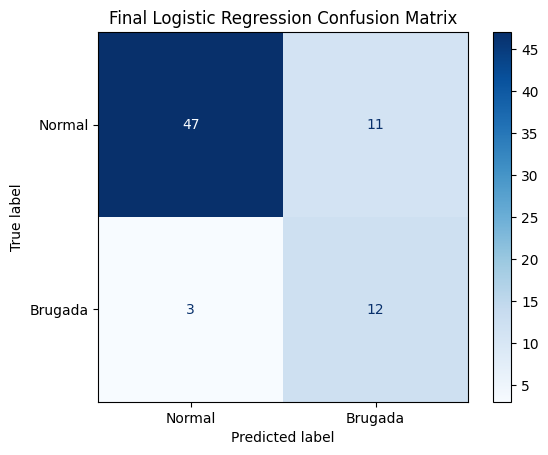

In [12]:
################ Logistic Regression (Method 2) ###############################

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

X2 = df.drop(['Patient_ID', 'Label'], axis=1)
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X2)
y = df['Label']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(class_weight='balanced', C=0.5, random_state=42))
])
scores = cross_val_score(pipeline, X2, y, cv=5, scoring='roc_auc')
print(f"AUC (Cross Validation): {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, stratify=y, random_state=42)
#X_train = scaler.fit_transform(X_train_raw)
#X_test = scaler.transform(X_test_raw)

pipeline.fit(X_train, y_train)

#log_model = LogisticRegression(class_weight='balanced', C=0.5, random_state=42)
#log_model.fit(X_train, y_train)

#coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_model.coef_[0]}).sort_values(by='Coefficient', ascending=False)
#print("Coefficients for all 18 features:")
#print(coef_df)

y_probs_log = pipeline.predict_proba(X_test)[:, 1]
y_pred_log = pipeline.predict(X_test)

print(f"\nTraining AUC: {roc_auc_score(y_test, y_probs_log):.4f}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_log)}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, display_labels=['Normal', 'Brugada'], cmap='Blues')
plt.title('Final Logistic Regression Confusion Matrix')
plt.show()

In [13]:
import joblib

# Save the complete pipeline containing the Scaler and Logistic Regression
joblib.dump(pipeline, 'brugada_model.pkl')

print("✅ The Ultimate AI Brain (Pipeline) has been successfully saved as brugada_model.pkl!")

✅ The Ultimate AI Brain (Pipeline) has been successfully saved as brugada_model.pkl!


               Feature  Coefficient
7          V2_ST_slope       1.5461
2   V1_95th_Percentile       1.0534
6       V2_J_point_amp       0.8837
13         V3_ST_slope       0.8047
5       V1_Min_Voltage       0.7349
0       V1_J_point_amp       0.5814
15          V3_Std_Dev       0.5084
12      V3_J_point_amp       0.4224
9           V2_Std_Dev       0.2308
10     V2_Peak_to_Peak       0.0801
11      V2_Min_Voltage       0.0585
1          V1_ST_slope      -0.0613
3           V1_Std_Dev      -0.0707
17      V3_Min_Voltage      -0.0739
8   V2_95th_Percentile      -0.1772
4      V1_Peak_to_Peak      -0.1839
16     V3_Peak_to_Peak      -0.4115
14  V3_95th_Percentile      -0.5549


/tmp/ipykernel_644/2689106220.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='RdBu_r')


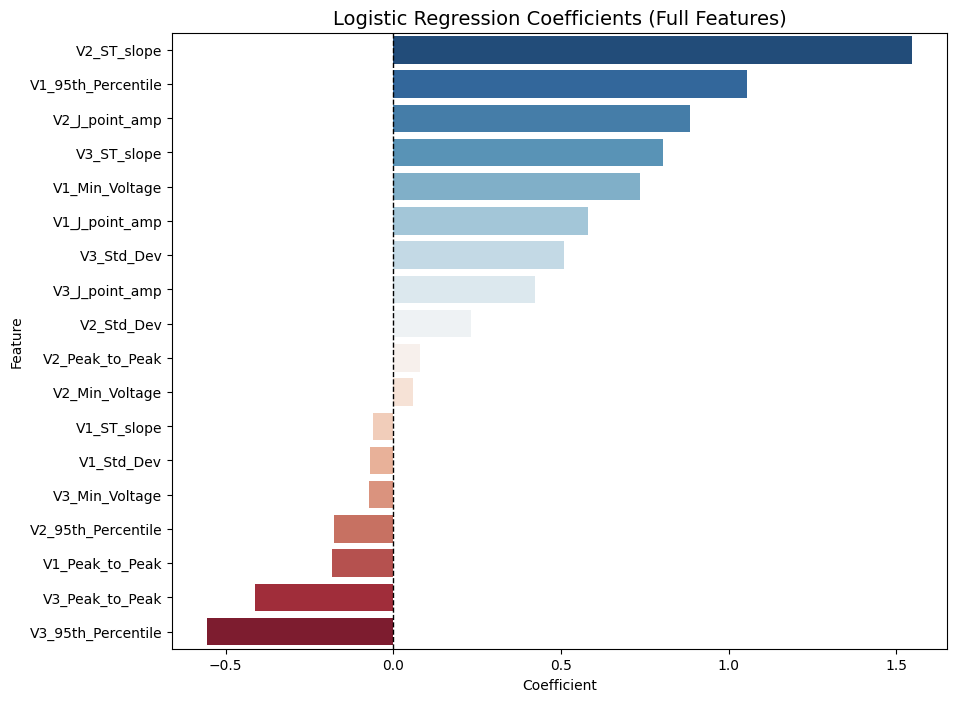

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

model_step = pipeline.named_steps['log_reg']
coefficients = model_step.coef_[0]
coef_df = pd.DataFrame({'Feature': X2.columns,'Coefficient': coefficients}).sort_values(by='Coefficient', ascending=False)
print(coef_df)

plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='RdBu_r')
plt.title('Logistic Regression Coefficients (Full Features)', fontsize=14)
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.show()

In [15]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# Logistic Regression
y_probs_log = pipeline.predict_proba(X_test)[:, 1]
y_pred_log = pipeline.predict(X_test)

log_metrics = {
    'Model': 'Logistic Regression (Linear)',
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Recall (Brugada)': recall_score(y_test, y_pred_log),
    'F1-Score': f1_score(y_test, y_pred_log),
    'AUC': roc_auc_score(y_test, y_probs_log)
}

# Random Forest
rf_metrics = {
    'Model': 'Random Forest (Non-linear)',
    'Accuracy': accuracy_score(y_test_all, y_pred_all),
    'Recall (Brugada)': recall_score(y_test_all, y_pred_all),
    'F1-Score': f1_score(y_test_all, y_pred_all),
    'AUC': roc_auc_score(y_test_all, y_probs_all)
}

comparison_df = pd.DataFrame([log_metrics, rf_metrics])
print(comparison_df.round(4))


                          Model  Accuracy  Recall (Brugada)  F1-Score    AUC
0  Logistic Regression (Linear)    0.8082            0.8000    0.6316 0.8586
1    Random Forest (Non-linear)    0.9041            0.5333    0.6957 0.9063
